In [2]:
import random
from collections import deque
from pathlib import Path

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import clear_output
from gymnasium import ObservationWrapper
from gymnasium.spaces import Box
from gymnasium.wrappers import FrameStackObservation
from gymnasium.wrappers import AtariPreprocessing
import cv2

In [3]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, obs, action, reward, next_obs, done):
        self.buffer.append((obs, action, reward, next_obs, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)

        obs = np.asarray(obs, dtype=np.float32)
        next_obs = np.asarray(next_obs, dtype=np.float32)

        obs = torch.from_numpy(obs) / 255.0
        next_obs = torch.from_numpy(next_obs) / 255.0

        actions = torch.tensor(actions, dtype=torch.long)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        dones = torch.tensor(dones, dtype=torch.float32)

        return obs, actions, rewards, next_obs, dones

    def __len__(self):
        return len(self.buffer)

In [4]:
class DQN(nn.Module):
    def __init__(self, obs_shape, n_actions):
        super().__init__()

        # obs_shape should be (4, 84, 84)
        c, h, w = obs_shape

        self.conv = nn.Sequential(
            nn.Conv2d(c, 32, kernel_size=8, stride=4),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, c, h, w)
            conv_out_size = self.conv(dummy).view(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(conv_out_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [5]:
class Agent:
    def __init__(
        self,
        obs_shape,
        n_actions,
        device,
        gamma=0.99,
        lr=1e-4,
    ):
        self.device = torch.device(device)
        self.n_actions = n_actions
        self.gamma = gamma

        # Online network: updated by gradient descent
        self.q_net = DQN(obs_shape, n_actions).to(self.device)

        # Target network: periodically copied from q_net
        self.target_net = DQN(obs_shape, n_actions).to(self.device)

        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(
            self.q_net.parameters(),
            lr=lr,
        )

    def select_action(self, obs, epsilon, action_space):
        """
        Select a random action with probability epsilon.
        Otherwise, select the action with the largest predicted Q-value.
        """
        if random.random() < epsilon:
            return action_space.sample()

        obs_t = torch.as_tensor(
            obs,
            dtype=torch.float32,
            device=self.device,
        )

        # Add the batch dimension:
        # (channels, height, width) -> (1, channels, height, width)
        obs_t = obs_t.unsqueeze(0) / 255.0

        self.q_net.eval()

        with torch.no_grad():
            q_values = self.q_net(obs_t)

        return q_values.argmax(dim=1).item()

    def learn(self, batch):
        """
        Perform one DQN gradient update.

        ReplayBuffer returns CPU tensors. Only this sampled minibatch
        is transferred to the selected training device.
        """
        obs, actions, rewards, next_obs, dones = (
            tensor.to(self.device)
            for tensor in batch
        )

        self.q_net.train()

        # Q(s, a) for the actions actually taken
        q_values = self.q_net(obs)

        action_q_values = q_values.gather(
            dim=1,
            index=actions.unsqueeze(1),
        ).squeeze(1)

        # Bellman targets:
        # reward + gamma * max_a Q_target(next_state, a)
        with torch.no_grad():
            next_q_values = self.target_net(next_obs)
            max_next_q_values = next_q_values.max(dim=1).values

            targets = (
                rewards
                + self.gamma
                * max_next_q_values
                * (1.0 - dones)
            )

        # Huber loss is commonly used for DQN because it is less
        # sensitive to large TD errors than ordinary MSE.
        loss = F.smooth_l1_loss(
            action_q_values,
            targets,
        )

        self.optimizer.zero_grad()
        loss.backward()

        # Helps prevent unusually large gradient updates.
        torch.nn.utils.clip_grad_norm_(
            self.q_net.parameters(),
            max_norm=10.0,
        )

        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        """
        Copy the online network weights into the target network.
        """
        self.target_net.load_state_dict(
            self.q_net.state_dict()
        )
        self.target_net.eval()

In [6]:
def make_env(visualize=False, seed=42):
    gym.register_envs(ale_py)

    env = gym.make(
        "ALE/Breakout-v5",
        frameskip=1,
        render_mode="human" if visualize else None,
    )

    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        grayscale_newaxis=False,
        scale_obs=False,
    )
    env = FrameStackObservation(env, stack_size=4)

    obs, info = env.reset(seed=seed)
    return env, obs, info

In [24]:
from collections import Counter


def evaluate(agent, episodes=5, max_steps=5000):
    env, obs, info = make_env(visualize=True)

    scores = []
    

    for episode in range(episodes):
        obs, info = env.reset()
        action_counts = Counter()
        # launch ball
        obs, reward, terminated, truncated, info = env.step(1)

        total_reward = 0
        lives = info.get("lives", 0)

        for step in range(max_steps):
            action = agent.select_action(
                obs,
                epsilon=0.01,
                action_space=env.action_space,
            )

            action_counts[action] += 1

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

            done = terminated or truncated
            new_lives = info.get("lives", lives)

            if new_lives < lives and not done:
                obs, fire_reward, terminated, truncated, info = env.step(1)
                total_reward += fire_reward
                done = terminated or truncated

            lives = info.get("lives", new_lives)

            if done:
                break

        scores.append(total_reward)
        print(f"Episode {episode + 1}: {total_reward}")
        print(action_counts)

    print(f"Average reward: {np.mean(scores):.2f}")
    return scores

In [8]:
import numpy as np

def moving_average(values, window=20):
    if len(values) < window:
        return []

    return np.convolve(
        values,
        np.ones(window) / window,
        mode="valid"
    )

In [9]:
def plot_training(episode_rewards, losses):

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)

    plt.plot(
        episode_rewards,
        alpha=0.3,
        label="Episode Reward"
    )

    if len(episode_rewards) >= 20:
        plt.plot(
            moving_average(episode_rewards, 20),
            linewidth=2,
            label="20 Episode Moving Average"
        )

    plt.title("Episode Reward")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(losses)
    plt.title("DQN Loss")
    plt.xlabel("Gradient Update")
    plt.ylabel("MSE Loss")

    plt.tight_layout()
    plt.show()

In [10]:
def save_checkpoint(path, agent, epsilon, step, episode, episode_rewards, losses):
    checkpoint = {
        "q_net_state_dict": agent.q_net.state_dict(),
        "optimizer_state_dict": agent.optimizer.state_dict(),
        "epsilon": epsilon,
        "step": step,
        "episode": episode,
        "episode_rewards": episode_rewards,
        "losses": losses,
        "target_net_state_dict": agent.target_net.state_dict()
    }

    torch.save(checkpoint, path)
    print(f"Saved checkpoint to {path}")

In [11]:
def load_checkpoint(path, agent, device):
    checkpoint = torch.load(
        path,
        map_location=device,
        weights_only=False,
    )

    agent.q_net.load_state_dict(
        checkpoint["q_net_state_dict"]
    )

    agent.target_net.load_state_dict(
        checkpoint["target_net_state_dict"]
    )

    agent.optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    agent.q_net.train()
    agent.target_net.eval()

    print(f"Loaded checkpoint from {path}")

    return {
        "epsilon": checkpoint["epsilon"],
        "step": checkpoint["step"],
        "episode": checkpoint["episode"],
        "episode_rewards": checkpoint["episode_rewards"],
        "losses": checkpoint["losses"],
    }

In [17]:
def train(
    agent,
    env,
    replay_buffer,
    num_steps=500_000,
    batch_size=64,
    epsilon=1.0,
    epsilon_min=0.1,
    epsilon_decay=0.999995,
    save_every=25_000,
    checkpoint_path="breakout_dqn_checkpoint.pt",
    start_step=0,
    start_episode=0,
    target_update_every=1_000,
    episode_rewards=None,
    losses=None,
    learning_starts=20_000,
):
    """
    Train a DQN agent for a fixed number of environment steps.

    Parameters
    ----------
    num_steps:
        Number of new environment interactions to perform during this run.

    target_update_every:
        Number of gradient updates between target-network synchronizations.

    learning_starts:
        Number of replay-buffer transitions required before training begins.
    """

    obs, info = env.reset()

    # Start Breakout by pressing FIRE.
    obs, _, terminated, truncated, info = env.step(1)

    # Very defensive check in case the FIRE action immediately ends the env.
    if terminated or truncated:
        obs, info = env.reset()
        obs, _, terminated, truncated, info = env.step(1)

    lives = info.get("lives", 0)

    episode_reward = 0.0
    episode = start_episode
    update_count = 0
    latest_loss = None

    if episode_rewards is None:
        episode_rewards = []

    if losses is None:
        losses = []

    for local_step in range(num_steps):
        global_step = start_step + local_step

        # Epsilon-greedy action selection
        action = agent.select_action(
            obs,
            epsilon,
            env.action_space,
        )

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        new_lives = info.get("lives", lives)

        # Breakout normally requires FIRE after losing a life.
        if new_lives < lives and not done:
            next_obs, fire_reward, terminated, truncated, info = env.step(1)

            reward += fire_reward
            done = terminated or truncated

        lives = info.get("lives", new_lives)

        # ReplayBuffer stores ordinary NumPy observations in system RAM.
        replay_buffer.add(
            obs,
            action,
            reward,
            next_obs,
            done,
        )

        episode_reward += reward

        # Start gradient updates after sufficient replay data exists.
        minimum_buffer_size = max(
            learning_starts,
            batch_size,
        )

        if len(replay_buffer) >= minimum_buffer_size:
            batch = replay_buffer.sample(batch_size)

            latest_loss = agent.learn(batch)

            losses.append(latest_loss)
            update_count += 1

            # Parentheses are required here to actually call the method.
            if update_count % target_update_every == 0:
                agent.update_target_network()

        if done:
            episode_rewards.append(episode_reward)

            episode += 1
            episode_reward = 0.0

            obs, info = env.reset()

            # Press FIRE to begin the new episode.
            obs, _, terminated, truncated, info = env.step(1)

            if terminated or truncated:
                obs, info = env.reset()
                obs, _, terminated, truncated, info = env.step(1)

            lives = info.get("lives", 0)

        else:
            obs = next_obs

        # Decay epsilon once per environment-loop iteration.
        epsilon = max(
            epsilon_min,
            epsilon * epsilon_decay,
        )

        if local_step % 500 == 0:
            clear_output(wait=True)

            print(f"Device: {agent.device}")
            print(f"Global step: {global_step:,}")
            print(f"Local step: {local_step:,}")
            print(f"Episode: {episode:,}")
            print(f"Gradient updates this run: {update_count:,}")
            print(f"Epsilon: {epsilon:.4f}")
            print(f"Replay buffer size: {len(replay_buffer):,}")

            if latest_loss is not None:
                print(f"Latest loss: {latest_loss:.5f}")

            if episode_rewards:
                print(
                    "Latest episode reward: "
                    f"{episode_rewards[-1]:.2f}"
                )

            plot_training(
                episode_rewards,
                losses,
            )

        # global_step represents a zero-based step index, so save the
        # number of completed steps as global_step + 1.
        completed_steps = global_step + 1

        if (
            completed_steps > 0
            and completed_steps % save_every == 0
        ):
            save_checkpoint(
                checkpoint_path,
                agent,
                epsilon,
                completed_steps,
                episode,
                episode_rewards,
                losses,
            )

    final_step = start_step + num_steps

    save_checkpoint(
        checkpoint_path,
        agent,
        epsilon,
        final_step,
        episode,
        episode_rewards,
        losses,
    )

    return (
        agent,
        epsilon,
        episode_rewards,
        losses,
    )

In [26]:
visualize = False

env, obs, info = make_env(visualize=visualize, seed=42)

CHECKPOINT_PATH = "breakout_dqn_checkpoint.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"
agent = Agent(obs.shape, env.action_space.n, device)
replay_buffer = ReplayBuffer(capacity=50_000)
epsilon = 0.1
start_step=0
start_episode=0
episode_rewards=[]
losses=[]
learning_starts = 20_000

In [27]:

if Path(CHECKPOINT_PATH).exists():
    checkpoint = load_checkpoint(
        CHECKPOINT_PATH,
        agent,
        device,
    )

    epsilon = checkpoint["epsilon"]
    start_step=checkpoint["step"]
    start_episode=checkpoint["episode"]
    episode_rewards=checkpoint["episode_rewards"]
    losses=checkpoint["losses"]
    learning_starts = 0

    print(f"Resuming from step {checkpoint['step']}")

else:
    print("No checkpoint found. Starting fresh.")

Loaded checkpoint from breakout_dqn_checkpoint.pt
Resuming from step 475000


In [ ]:
# #Laptop

# agent, epsilon, episode_rewards, losses = train(
#     agent,
#     env,
#     replay_buffer,
#     num_steps=5000,
#     epsilon=epsilon,
#     start_step=start_step,
#     start_episode=start_episode,
#     episode_rewards=episode_rewards,
#     losses=losses,
# )

NameError: name 'train' is not defined

Device: cuda
Global step: 575,500
Local step: 100,500
Episode: 1,780
Gradient updates this run: 100,438
Epsilon: 0.1000
Replay buffer size: 50,000
Latest loss: 0.00256
Latest episode reward: 9.00


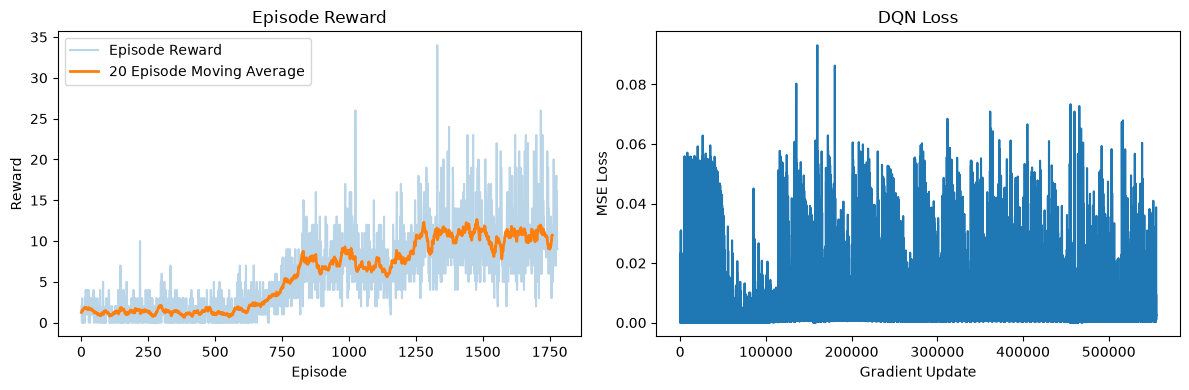

KeyboardInterrupt: 

In [28]:
# PC

agent, epsilon, episode_rewards, losses = train(
    agent,
    env,
    replay_buffer,
    num_steps=500_000,
    batch_size=64,
    save_every=25_000,
    target_update_every=5_000,
    learning_starts=learning_starts,
    epsilon=epsilon,
    start_step=start_step,
    start_episode=start_episode,
    episode_rewards=episode_rewards,
    losses=losses,
)

In [25]:
evaluate(agent, episodes=5)

Episode 1: 6.0
Counter({2: 109, 0: 108, 3: 87, 1: 32})
Episode 2: 5.0
Counter({3: 118, 2: 112, 0: 62, 1: 36})
Episode 3: 15.0
Counter({0: 232, 3: 132, 2: 114, 1: 84})
Episode 4: 16.0
Counter({3: 213, 2: 200, 0: 122, 1: 61})
Episode 5: 17.0
Counter({3: 265, 0: 192, 1: 132, 2: 130})
Average reward: 11.80


[6.0, 5.0, 15.0, 16.0, 17.0]